# 招聘数据探索性分析 (EDA)

**分析目标：** 对招聘数据总表进行全面的探索性分析，了解数据的基本结构、质量和特征

**数据源：** `datas/src/招聘数据总表_2510.xlsx`


## 先解决一下中文显示的问题

In [1]:
!pip install wanglaoshi

Looking in indexes: https://mirrors.aliyun.com/pypi/simple/

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
# 这里用的是 SimHei 字体，可以根据自己的需要更改
from wanglaoshi import JupyterFont as JF
JF.matplotlib_font_init()

## 1. 环境准备

**分析动机：** 在开始数据分析前，需要导入必要的Python库。这些库为我们提供了数据处理、分析和可视化的功能。

- `pandas`: 用于数据读取、清洗和分析
- `numpy`: 用于数值计算
- `matplotlib & seaborn`: 用于数据可视化
- `warnings`: 用于控制警告信息的显示


In [3]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 设置显示选项
pd.set_option('display.max_columns', None)  # 显示所有列
pd.set_option('display.max_rows', 100)      # 最多显示100行
pd.set_option('display.width', None)        # 自动调整显示宽度
pd.set_option('display.max_colwidth', 50)   # 列内容最大显示宽度

# 设置中文显示（macOS）
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macOS 中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 设置图表样式
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 忽略警告
warnings.filterwarnings('ignore')

print("✅ 环境准备完成！")


✅ 环境准备完成！


## 2. Excel 文件结构分析

**分析动机：** Excel 文件可能包含多个工作表(sheet)，在读取数据之前，我们需要先了解文件包含哪些 sheet，这样可以：
1. 全面了解数据的组织结构
2. 确定哪些 sheet 需要分析
3. 避免遗漏重要数据
4. 为后续的数据读取做准备


In [4]:
# 定义文件路径
file_path = 'datas/src/招聘数据总表_2510.xlsx'

# 查看 Excel 文件包含的所有 sheet
excel_file = pd.ExcelFile(file_path)
sheet_names = excel_file.sheet_names

print(f"📊 Excel 文件包含 {len(sheet_names)} 个工作表：")
print("=" * 60)
for i, sheet in enumerate(sheet_names, 1):
    print(f"{i}. {sheet}")
print("=" * 60)


📊 Excel 文件包含 8 个工作表：
1. 营销类
2. 运营类
3. 产品类
4. 管培类
5. 财会类
6. 编程类
7. 金融中台
8. 数据类


## 3. 数据加载

**分析动机：** 了解了文件结构后，需要将数据加载到内存中进行分析。我们首先读取第一个 sheet 作为主要分析对象。如果有多个 sheet，会逐一进行探索。


In [5]:
# 读取所有 sheet 到字典中
dfs = {}
for sheet in sheet_names:
    dfs[sheet] = pd.read_excel(file_path, sheet_name=sheet)
    print(f"✅ 已加载: {sheet} - 形状: {dfs[sheet].shape}")

# 获取第一个 sheet 作为主要分析对象
main_sheet_name = sheet_names[0]
df = dfs[main_sheet_name]

print(f"\n📌 主要分析对象: {main_sheet_name}")
print(f"   数据维度: {df.shape[0]} 行 × {df.shape[1]} 列")


✅ 已加载: 营销类 - 形状: (8702, 19)
✅ 已加载: 运营类 - 形状: (9091, 20)
✅ 已加载: 产品类 - 形状: (7026, 20)
✅ 已加载: 管培类 - 形状: (2261, 19)
✅ 已加载: 财会类 - 形状: (4851, 19)
✅ 已加载: 编程类 - 形状: (8629, 21)
✅ 已加载: 金融中台 - 形状: (4186, 19)
✅ 已加载: 数据类 - 形状: (6583, 15)

📌 主要分析对象: 营销类
   数据维度: 8702 行 × 19 列


## 4. 数据基本信息

**分析动机：** 在深入分析之前，需要先了解数据的基本情况：
1. **查看前几行数据** - 直观了解数据的内容和格式
2. **列名和数据类型** - 了解有哪些字段，每个字段存储什么类型的数据
3. **内存使用情况** - 评估数据规模，为后续处理做准备

这些信息能帮助我们快速建立对数据的整体认知。


In [6]:
# 查看数据前5行
print("📋 数据预览（前5行）：")
print("=" * 80)
display(df.head())


📋 数据预览（前5行）：


,岗位名称,岗位薪资,公司名称,公司部门,公司行业,公司阶段,公司规模,公司地址,经验要求,学历要求,岗位类别,岗位类型,岗位福利,岗位要求,最低月薪,最高月薪,薪资月,平均年薪/K,公司分级
0,销售经理 金融行业（银行、证券、保险）,25k-50k,趋动科技,趋动科技,人工智能服务,B轮,NaN,北京,经验5-10年,大专及以上,客户经理,全职,六险一金，弹性工作，期权激励，绩效奖金,职位描述：职位描述： \n1.建立良好的客户关系；与应用需求部门、平台部门、基础架构及采购等...,25.0,50.0,12,450.0,B
1,销售经理（上海保险） (MJ000644),15k-22k·15薪,百融云创,百融云创保险销售部,"科技金融,人工智能服务",上市公司,NaN,上海,经验5-10年,本科及以上,客户经理,全职,平台稳定，发展空间大,职位描述：岗位职责: \n1、独立开展保险行业线业务销售； \n2、挖掘保险公司不同部门的业...,15.0,22.0,15,277.5,B
2,保险公司客户经理,8k-12k,中信保诚人寿,中信保诚人寿银保部,金融业,上市公司,2000人以上,北京,经验1-3年,本科及以上,客户经理,全职,收入高 升职空间大,职位描述：一、职责描述： \n1、渠道维护资讯整理：通过与银行渠道相应人员沟通包括影响业务开...,8.0,12.0,12,120.0,B
3,保险顾问,6k-8k·15薪,中国平安人寿保险股份有限公司上海电话销售中心,中国平安人寿保险股份有限公司上海电话销售中心,金融业,上市公司,2000人以上,上海,经验不限,大专及以上,客户经理,全职,免费班车+高低温补贴+四大食堂,职位描述：岗位职责：\n1.依托公司平台，通过电话、企业微信、网络等远程形式，借助公司提供的...,6.0,8.0,15,105.0,B
4,保险产品培训岗,15k-25k,水滴公司WATERDROP INC.,水滴公司WATERDROP INC.,科技金融,上市公司,NaN,北京,经验3-5年,本科及以上,客户经理,全职,团队氛围好 成长空间大,职位描述：保险产品培训岗工作职责：1、与培训部协同，对内对外输出经纪渠道产品（含互联网产品）...,15.0,25.0,12,240.0,B


In [7]:
# 查看数据信息
print("📊 数据集基本信息：")
print("=" * 80)
df.info()

📊 数据集基本信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8702 entries, 0 to 8701
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   岗位名称    8702 non-null   object 
 1   岗位薪资    8494 non-null   object 
 2   公司名称    8638 non-null   object 
 3   公司部门    8301 non-null   object 
 4   公司行业    8577 non-null   object 
 5   公司阶段    8278 non-null   object 
 6   公司规模    7183 non-null   object 
 7   公司地址    8578 non-null   object 
 8   经验要求    8639 non-null   object 
 9   学历要求    8639 non-null   object 
 10  岗位类别    8702 non-null   object 
 11  岗位类型    8631 non-null   object 
 12  岗位福利    8581 non-null   object 
 13  岗位要求    8582 non-null   object 
 14  最低月薪    8494 non-null   float64
 15  最高月薪    8494 non-null   float64
 16  薪资月     8702 non-null   int64  
 17  平均年薪/K  8702 non-null   float64
 18  公司分级    8352 non-null   object 
dtypes: float64(3), int64(1), object(15)
memory usage: 1.3+ MB


In [8]:
# 查看列名
print("📝 数据集包含的所有列：")
print("=" * 80)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")
print(f"\n共 {len(df.columns)} 列")


📝 数据集包含的所有列：
 1. 岗位名称
 2. 岗位薪资
 3. 公司名称
 4. 公司部门
 5. 公司行业
 6. 公司阶段
 7. 公司规模
 8. 公司地址
 9. 经验要求
10. 学历要求
11. 岗位类别
12. 岗位类型
13. 岗位福利
14. 岗位要求
15. 最低月薪
16. 最高月薪
17. 薪资月
18. 平均年薪/K
19. 公司分级

共 19 列


## 5. 数据质量检查

**分析动机：** 数据质量直接影响分析结果的可靠性。通过检查数据质量，我们可以：

1. **缺失值检查** - 识别哪些字段存在数据缺失，缺失比例有多高
2. **重复值检查** - 发现是否存在重复记录，避免数据重复统计
3. **数据一致性** - 初步判断数据是否存在异常或不合理的值

这些检查帮助我们：
- 评估数据的完整性和可靠性
- 决定是否需要进行数据清洗
- 为后续的分析策略提供依据


### 5.1 缺失值检查

In [9]:
# 缺失值统计
print("🔍 缺失值检查：")
print("=" * 80)

missing_stats = pd.DataFrame({
    '缺失数量': df.isnull().sum(),
    '缺失比例(%)': (df.isnull().sum() / len(df) * 100).round(2)
})

# 只显示有缺失值的列
missing_stats = missing_stats[missing_stats['缺失数量'] > 0].sort_values('缺失数量', ascending=False)

if len(missing_stats) > 0:
    display(missing_stats)
    print(f"\n⚠️  共有 {len(missing_stats)} 个字段存在缺失值")
else:
    print("✅ 数据完整，没有缺失值！")


🔍 缺失值检查：


,缺失数量,缺失比例(%)
公司规模,1519,17.46
公司阶段,424,4.87
公司部门,401,4.61
公司分级,350,4.02
岗位薪资,208,2.39
最低月薪,208,2.39
最高月薪,208,2.39
公司行业,125,1.44
公司地址,124,1.42
岗位福利,121,1.39



⚠️  共有 15 个字段存在缺失值


### 5.2 重复值检查

In [10]:
# 重复值检查
print("🔍 重复值检查：")
print("=" * 80)

duplicates = df.duplicated().sum()
print(f"重复行数量: {duplicates}")
print(f"重复比例: {(duplicates/len(df)*100):.2f}%")

if duplicates > 0:
    print(f"\n⚠️  发现 {duplicates} 条重复记录，建议后续处理时考虑去重")
else:
    print("\n✅ 没有发现重复记录")


🔍 重复值检查：
重复行数量: 20
重复比例: 0.23%

⚠️  发现 20 条重复记录，建议后续处理时考虑去重


## 6. 描述性统计分析

**分析动机：** 描述性统计是理解数据分布特征的基础方法。通过统计分析，我们可以：

1. **数值型数据统计** - 了解数值字段的中心趋势（均值、中位数）和离散程度（标准差、四分位数）
2. **分类型数据统计** - 了解文本字段的唯一值数量、最常见的值等
3. **数据分布特征** - 发现数据的偏态、异常值等特征

这些统计指标能帮助我们：
- 快速把握数据的整体特征
- 发现潜在的数据问题
- 为深入分析指明方向


### 6.1 数值型字段的描述性统计

In [11]:
# 数值型字段的描述性统计
print("📊 数值型字段统计摘要：")
print("=" * 80)

numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    display(df[numeric_cols].describe())
else:
    print("⚠️  数据集中没有数值型字段")


📊 数值型字段统计摘要：


,最低月薪,最高月薪,薪资月,平均年薪/K
count,8494.000000,8494.000000,8702.000000,8702.000000
mean,10.296562,17.981634,12.315330,171.222420
std,6.717736,11.992860,1.055234,120.765669
min,1.000000,2.000000,12.000000,0.000000
25%,6.000000,10.000000,12.000000,105.000000
50%,8.000000,15.000000,12.000000,144.000000
75%,12.000000,20.000000,12.000000,210.000000
max,150.000000,300.000000,24.000000,2700.000000


### 6.2 文本型字段的统计分析

In [12]:
# 文本型字段的统计分析
print("📝 文本型字段统计摘要：")
print("=" * 80)

object_cols = df.select_dtypes(include=['object']).columns
if len(object_cols) > 0:
    for col in object_cols[:10]:  # 显示前10个文本字段
        unique_count = df[col].nunique()
        top_value = df[col].value_counts().head(1)
        print(f"\n字段: {col}")
        print(f"  唯一值数量: {unique_count}")
        if len(top_value) > 0:
            print(f"  最常见值: {top_value.index[0]} (出现 {top_value.values[0]} 次)")
        print("-" * 60)
else:
    print("⚠️  数据集中没有文本型字段")


📝 文本型字段统计摘要：

字段: 岗位名称
  唯一值数量: 6586
  最常见值: 房产经纪人 (出现 64 次)
------------------------------------------------------------

字段: 岗位薪资
  唯一值数量: 494
  最常见值: 10k-20k (出现 623 次)
------------------------------------------------------------

字段: 公司名称
  唯一值数量: 4136
  最常见值: 北京麦田 (出现 598 次)
------------------------------------------------------------

字段: 公司部门
  唯一值数量: 4950
  最常见值: 北京麦田 (出现 382 次)
------------------------------------------------------------

字段: 公司行业
  唯一值数量: 1000
  最常见值: 居住服务 (出现 838 次)
------------------------------------------------------------

字段: 公司阶段
  唯一值数量: 71
  最常见值: 不需要融资 (出现 2691 次)
------------------------------------------------------------

字段: 公司规模
  唯一值数量: 43
  最常见值: 2000人以上 (出现 2211 次)
------------------------------------------------------------

字段: 公司地址
  唯一值数量: 58
  最常见值: 北京 (出现 2496 次)
------------------------------------------------------------

字段: 经验要求
  唯一值数量: 7
  最常见值: 在校应届  (出现 2516 次)
------------------------------------------------------------

字段: 学

## 7. 数据可视化分析

**分析动机：** "一图胜千言"，可视化能够直观地展示数据的分布和特征。通过可视化，我们可以：

1. **缺失值可视化** - 直观看到哪些字段缺失最严重
2. **数值分布可视化** - 了解数值型数据的分布形态（正态、偏态等）
3. **分类数据可视化** - 查看分类字段的频次分布

可视化的优势：
- 快速发现数据模式和异常
- 更容易理解复杂的数据关系
- 为后续深入分析提供线索


In [13]:
# 这里用的是 SimHei 字体，可以根据自己的需要更改
from wanglaoshi import JupyterFont as JF
JF.matplotlib_font_init()

📊 缺失值分布可视化


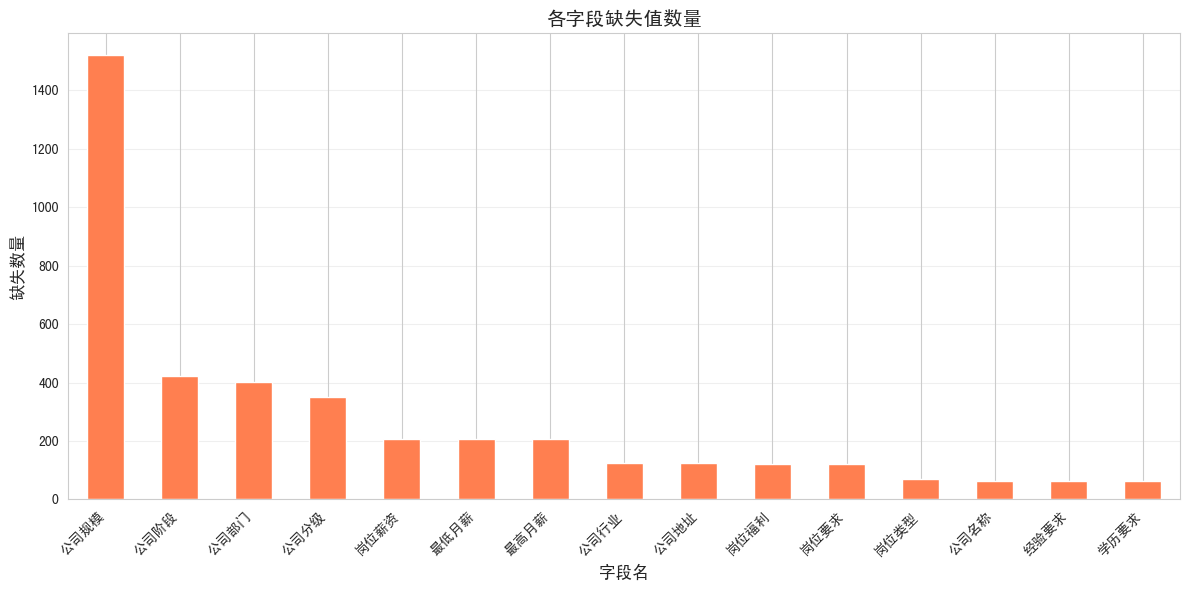

In [14]:
# 缺失值可视化
print("📊 缺失值分布可视化")
print("=" * 80)

missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if len(missing_data) > 0:
    plt.figure(figsize=(12, 6))
    missing_data.plot(kind='bar', color='coral')
    plt.title('各字段缺失值数量', fontsize=14, fontweight='bold')
    plt.xlabel('字段名', fontsize=12)
    plt.ylabel('缺失数量', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("✅ 没有缺失值，无需可视化")


📊 数值型字段分布可视化


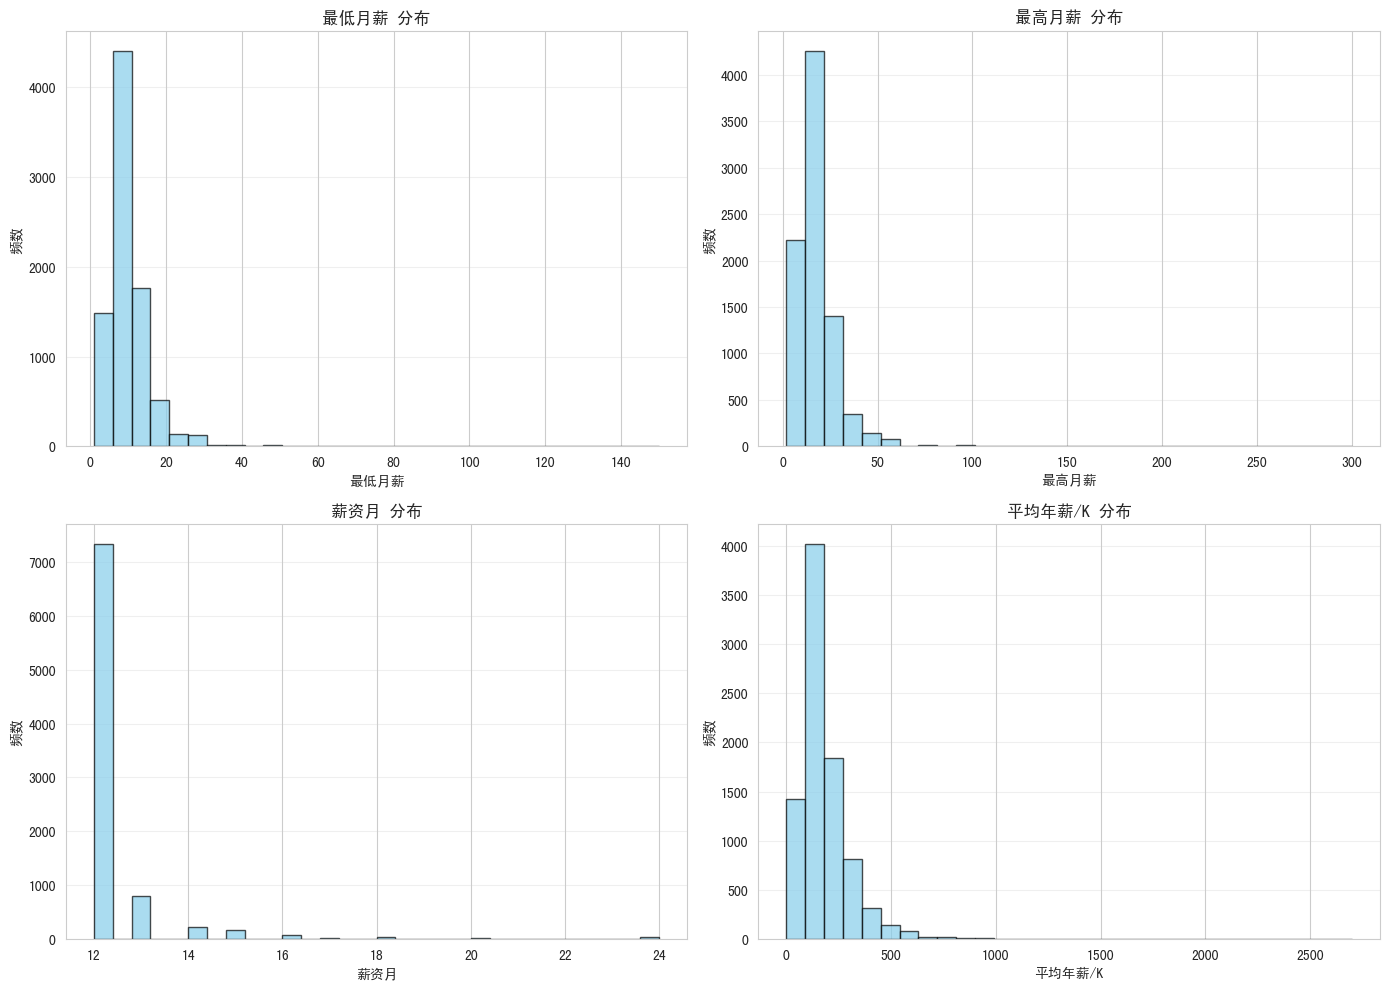

In [15]:
# 数值型字段分布可视化（显示前4个数值字段）
print("📊 数值型字段分布可视化")
print("=" * 80)

if len(numeric_cols) > 0:
    # 选择前4个数值字段进行可视化
    cols_to_plot = numeric_cols[:4]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.ravel()
    
    for idx, col in enumerate(cols_to_plot):
        if idx < len(axes):
            # 绘制直方图
            axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
            axes[idx].set_title(f'{col} 分布', fontsize=12, fontweight='bold')
            axes[idx].set_xlabel(col, fontsize=10)
            axes[idx].set_ylabel('频数', fontsize=10)
            axes[idx].grid(axis='y', alpha=0.3)
    
    # 隐藏多余的子图
    for idx in range(len(cols_to_plot), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  没有数值型字段可以可视化")


📊 分类字段频次分布可视化


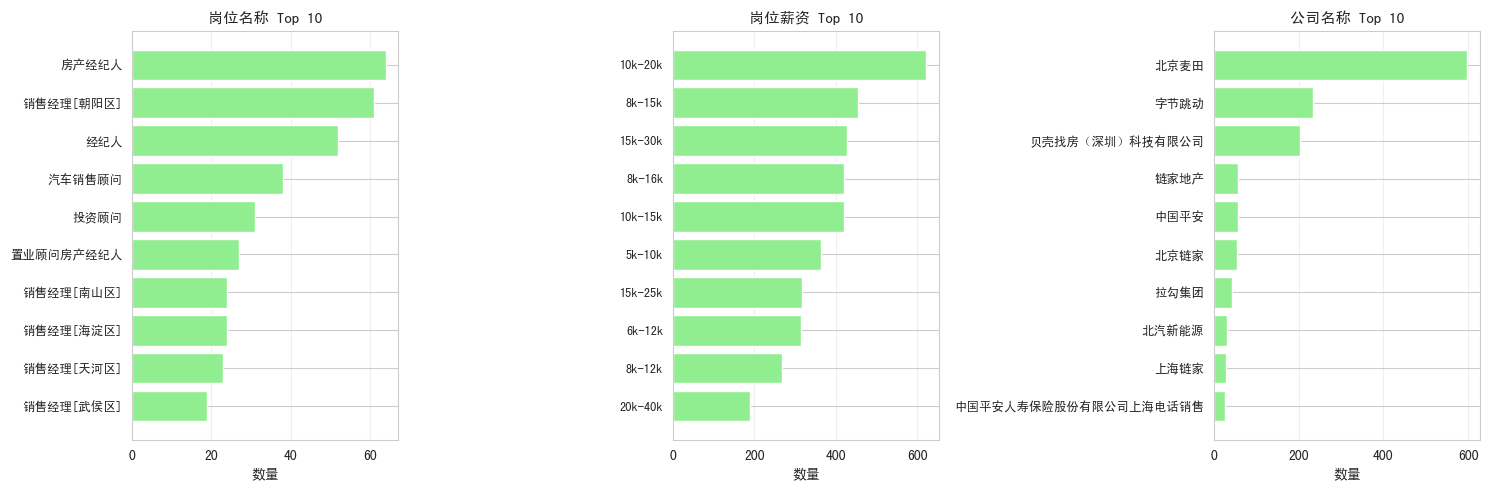

In [16]:
# 分类字段TOP值可视化（显示前3个文本字段的前10个最常见值）
print("📊 分类字段频次分布可视化")
print("=" * 80)

if len(object_cols) > 0:
    # 选择前3个文本字段
    cols_to_plot = object_cols[:3]
    
    fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(15, 5))
    
    # 如果只有一个字段，axes不是数组，需要转换
    if len(cols_to_plot) == 1:
        axes = [axes]
    
    for idx, col in enumerate(cols_to_plot):
        top_values = df[col].value_counts().head(10)
        axes[idx].barh(range(len(top_values)), top_values.values, color='lightgreen')
        axes[idx].set_yticks(range(len(top_values)))
        axes[idx].set_yticklabels([str(val)[:20] for val in top_values.index], fontsize=9)
        axes[idx].set_title(f'{col} Top 10', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('数量', fontsize=10)
        axes[idx].invert_yaxis()
        axes[idx].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  没有文本型字段可以可视化")


## 8. 数据概览总结

**分析动机：** 在完成初步探索后，需要对数据进行全面总结，形成对数据的整体认知。

这个总结帮助我们：
1. 梳理已经发现的关键信息
2. 识别需要进一步关注的问题
3. 为下一步的深入分析制定计划


In [17]:
# 生成数据概览报告
print("=" * 80)
print(" " * 25 + "📋 数据探索分析总结报告")
print("=" * 80)

print(f"\n【数据基本信息】")
print(f"  • 数据集名称: {main_sheet_name}")
print(f"  • 数据维度: {df.shape[0]:,} 行 × {df.shape[1]} 列")
print(f"  • 内存占用: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n【字段类型分布】")
print(f"  • 数值型字段: {len(numeric_cols)} 个")
print(f"  • 文本型字段: {len(object_cols)} 个")
print(f"  • 其他类型字段: {len(df.columns) - len(numeric_cols) - len(object_cols)} 个")

print(f"\n【数据质量评估】")
missing_count = df.isnull().sum().sum()
missing_ratio = (missing_count / (df.shape[0] * df.shape[1]) * 100)
print(f"  • 总缺失值数量: {missing_count:,}")
print(f"  • 总体缺失率: {missing_ratio:.2f}%")
print(f"  • 有缺失值的字段: {len(missing_stats) if len(missing_stats) > 0 else 0} 个")
print(f"  • 重复记录数: {duplicates}")

print(f"\n【下一步分析建议】")
print(f"  1. 根据业务需求，选择关键字段进行深入分析")
print(f"  2. 处理缺失值和重复值（如需要）")
print(f"  3. 进行相关性分析，发现字段间的关联关系")
print(f"  4. 针对具体业务问题，进行专项分析")

print("\n" + "=" * 80)
print(" " * 30 + "分析完成！✅")
print("=" * 80)


                         📋 数据探索分析总结报告

【数据基本信息】
  • 数据集名称: 营销类
  • 数据维度: 8,702 行 × 19 列
  • 内存占用: 19.57 MB

【字段类型分布】
  • 数值型字段: 4 个
  • 文本型字段: 15 个
  • 其他类型字段: 0 个

【数据质量评估】
  • 总缺失值数量: 4,069
  • 总体缺失率: 2.46%
  • 有缺失值的字段: 15 个
  • 重复记录数: 20

【下一步分析建议】
  1. 根据业务需求，选择关键字段进行深入分析
  2. 处理缺失值和重复值（如需要）
  3. 进行相关性分析，发现字段间的关联关系
  4. 针对具体业务问题，进行专项分析

                              分析完成！✅


## 9. 多 Sheet 对比分析（如果存在多个sheet）

**分析动机：** 如果 Excel 文件包含多个工作表，我们需要了解各个 sheet 的数据规模和结构差异。

这有助于：
1. 了解各个 sheet 的数据量和复杂度
2. 判断 sheet 之间是否存在关联
3. 确定后续是否需要整合多个 sheet 的数据

**字段对比分析的价值：**
- 发现所有 sheet 的字段全集，了解完整的数据维度
- 识别各 sheet 的共同字段和独有字段
- 评估数据结构的一致性
- 为数据合并或整合提供依据


📊 多个工作表对比分析


,Sheet名称,行数,列数,缺失值总数,缺失率(%),重复行数,内存(MB)
0,营销类,8702,19,4069,2.46,20,19.57
1,运营类,9091,20,820,0.45,0,19.28
2,产品类,7026,20,17301,12.31,39,13.65
3,管培类,2261,19,3966,9.23,310,8.27
4,财会类,4851,19,22760,24.69,901,9.84
5,编程类,8629,21,10478,5.78,2427,19.12
6,金融中台,4186,19,10681,13.43,331,7.92
7,数据类,6583,15,1299,1.32,1431,20.90


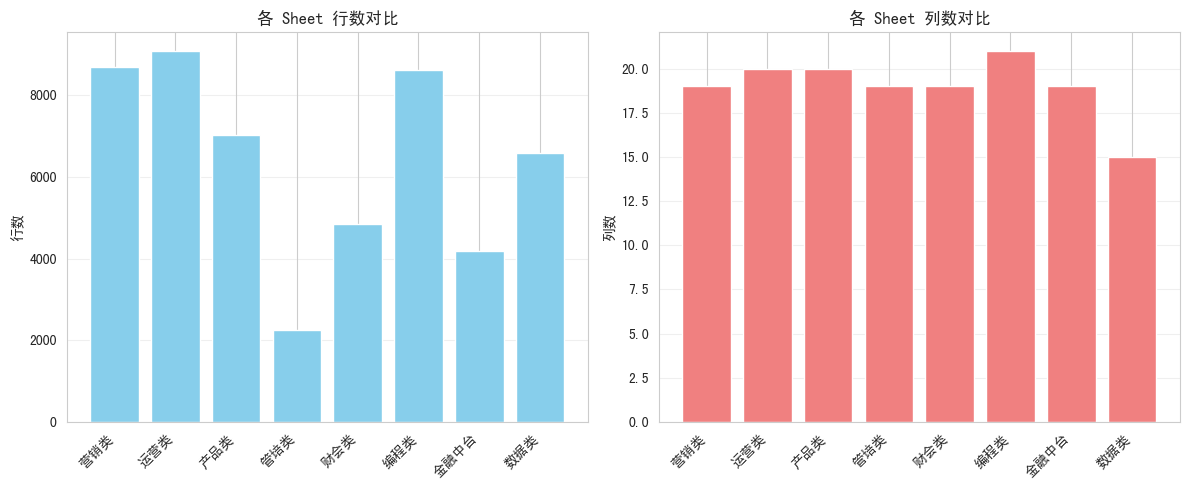

In [18]:
# 如果有多个 sheet，进行对比分析
if len(sheet_names) > 1:
    print("📊 多个工作表对比分析")
    print("=" * 80)
    
    # 创建对比表
    comparison_data = []
    for sheet in sheet_names:
        sheet_df = dfs[sheet]
        comparison_data.append({
            'Sheet名称': sheet,
            '行数': sheet_df.shape[0],
            '列数': sheet_df.shape[1],
            '缺失值总数': sheet_df.isnull().sum().sum(),
            '缺失率(%)': f"{(sheet_df.isnull().sum().sum() / (sheet_df.shape[0] * sheet_df.shape[1]) * 100):.2f}",
            '重复行数': sheet_df.duplicated().sum(),
            '内存(MB)': f"{sheet_df.memory_usage(deep=True).sum() / 1024**2:.2f}"
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    display(comparison_df)
    
    # 可视化各个 sheet 的数据量
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.bar(range(len(sheet_names)), [dfs[s].shape[0] for s in sheet_names], color='skyblue')
    plt.xticks(range(len(sheet_names)), sheet_names, rotation=45, ha='right')
    plt.title('各 Sheet 行数对比', fontsize=12, fontweight='bold')
    plt.ylabel('行数', fontsize=10)
    plt.grid(axis='y', alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.bar(range(len(sheet_names)), [dfs[s].shape[1] for s in sheet_names], color='lightcoral')
    plt.xticks(range(len(sheet_names)), sheet_names, rotation=45, ha='right')
    plt.title('各 Sheet 列数对比', fontsize=12, fontweight='bold')
    plt.ylabel('列数', fontsize=10)
    plt.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️  只有一个工作表，无需对比分析")



📋 各 Sheet 字段对比分析

✓ 所有 Sheet 的字段并集: 42 个字段
  字段列表: Unnamed: 0, 公司位置, 公司分级, 公司名称, 公司地址, 公司行业, 公司规模, 公司部门, 公司阶段, 学历要求...

📊 字段存在性矩阵:
字段对比表（共 42 个字段）：


,字段名,营销类,运营类,产品类,管培类,财会类,编程类,金融中台,数据类
0,Unnamed: 0,✗,✓,✗,✗,✗,✗,✗,✗
1,公司位置,✗,✓,✓,✓,✓,✓,✓,✓
2,公司分级,✓,✓,✓,✓,✓,✓,✓,✓
3,公司名称,✓,✓,✓,✓,✓,✓,✓,✓
4,公司地址,✓,✗,✗,✗,✗,✗,✗,✗
5,公司行业,✓,✗,✗,✗,✗,✗,✗,✗
6,公司规模,✓,✓,✓,✓,✓,✓,✓,✓
7,公司部门,✓,✗,✗,✓,✗,✓,✗,✗
8,公司阶段,✓,✓,✓,✓,✓,✓,✓,✓
9,学历要求,✓,✓,✓,✓,✓,✓,✓,✓



📈 各 Sheet 字段覆盖率:
--------------------------------------------------------------------------------


,Sheet名称,字段数,覆盖率(%),独有字段数,独有字段
0,营销类,19,45.2,7,"公司地址, 经验要求, 岗位福利..."
1,运营类,20,47.6,2,"Unnamed: 0, 工资月数"
2,产品类,20,47.6,3,"最高工资, 最低工资, 实习"
3,管培类,19,45.2,0,无
4,财会类,19,45.2,1,资
5,编程类,21,50.0,2,"月.1, 平均薪资"
6,金融中台,19,45.2,3,"最低月薪（千人名币）, 最高月薪（千人名币）, 平均年薪（千人名币）"
7,数据类,15,35.7,0,无


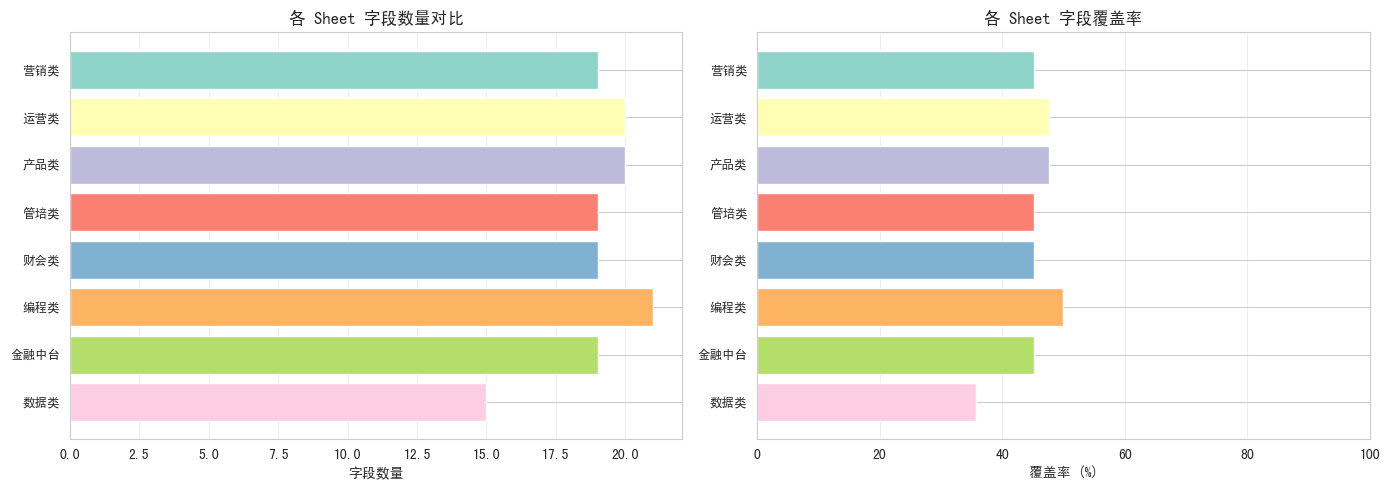


🔍 字段集合分析:
--------------------------------------------------------------------------------
✓ 共同字段 (所有 Sheet 都包含): 8 个
  公司分级, 公司名称, 公司规模, 公司阶段, 学历要求, 岗位名称, 岗位类型, 岗位要求

✓ 各 Sheet 独有字段:
  • 营销类: 7 个
    公司地址, 公司行业, 岗位福利, 岗位类别, 岗位薪资, 平均年薪/K, 经验要求
  • 运营类: 2 个
    Unnamed: 0, 工资月数
  • 产品类: 3 个
    实习, 最低工资, 最高工资
  • 管培类: 0 个
  • 财会类: 1 个
    资
  • 编程类: 2 个
    平均薪资, 月.1
  • 金融中台: 3 个
    平均年薪（千人名币）, 最低月薪（千人名币）, 最高月薪（千人名币）
  • 数据类: 0 个

💡 建议:
  • 如果需要合并多个 Sheet，需要处理字段不一致的问题
  • 共同字段可以作为合并的基础
  • 独有字段可能包含该 Sheet 特有的业务信息


In [19]:
# 字段对比分析
if len(sheet_names) > 1:
    print("\n" + "=" * 80)
    print("📋 各 Sheet 字段对比分析")
    print("=" * 80)
    
    # 1. 获取所有 sheet 的字段并集（最大整体集合）
    all_columns = set()
    for sheet in sheet_names:
        all_columns.update(dfs[sheet].columns.tolist())
    
    all_columns = sorted(list(all_columns))  # 排序便于查看
    
    print(f"\n✓ 所有 Sheet 的字段并集: {len(all_columns)} 个字段")
    print(f"  字段列表: {', '.join(all_columns[:10])}{'...' if len(all_columns) > 10 else ''}")
    
    # 2. 创建字段对比矩阵
    print(f"\n📊 字段存在性矩阵:")
    print("=" * 80)
    
    # 构建对比数据
    field_comparison = []
    for col in all_columns:
        row_data = {'字段名': col}
        for sheet in sheet_names:
            # 检查该字段是否存在于当前 sheet
            if col in dfs[sheet].columns:
                row_data[sheet] = '✓'
            else:
                row_data[sheet] = '✗'
        field_comparison.append(row_data)
    
    comparison_df = pd.DataFrame(field_comparison)
    
    # 显示完整的对比表
    print(f"字段对比表（共 {len(comparison_df)} 个字段）：")
    display(comparison_df)
    
    # 3. 统计每个 Sheet 的字段覆盖情况
    print(f"\n📈 各 Sheet 字段覆盖率:")
    print("-" * 80)
    
    coverage_stats = []
    for sheet in sheet_names:
        sheet_cols = set(dfs[sheet].columns)
        coverage = len(sheet_cols) / len(all_columns) * 100
        unique_fields = sheet_cols - set().union(*[set(dfs[s].columns) for s in sheet_names if s != sheet])
        
        coverage_stats.append({
            'Sheet名称': sheet,
            '字段数': len(sheet_cols),
            '覆盖率(%)': f"{coverage:.1f}",
            '独有字段数': len(unique_fields),
            '独有字段': ', '.join(list(unique_fields)[:3]) + ('...' if len(unique_fields) > 3 else '') if unique_fields else '无'
        })
    
    coverage_df = pd.DataFrame(coverage_stats)
    display(coverage_df)
    
    # 4. 可视化字段覆盖情况
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 左图：各 Sheet 字段数量
    sheet_field_counts = [len(dfs[s].columns) for s in sheet_names]
    colors_palette = plt.cm.Set3(range(len(sheet_names)))
    
    ax1.barh(range(len(sheet_names)), sheet_field_counts, color=colors_palette)
    ax1.set_yticks(range(len(sheet_names)))
    ax1.set_yticklabels(sheet_names, fontsize=9)
    ax1.set_xlabel('字段数量', fontsize=10)
    ax1.set_title('各 Sheet 字段数量对比', fontsize=12, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    # 右图：字段覆盖率
    coverage_values = [float(c['覆盖率(%)']) for c in coverage_stats]
    
    ax2.barh(range(len(sheet_names)), coverage_values, color=colors_palette)
    ax2.set_yticks(range(len(sheet_names)))
    ax2.set_yticklabels(sheet_names, fontsize=9)
    ax2.set_xlabel('覆盖率 (%)', fontsize=10)
    ax2.set_title('各 Sheet 字段覆盖率', fontsize=12, fontweight='bold')
    ax2.set_xlim(0, 100)
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 5. 找出共同字段和各自独有字段
    print(f"\n🔍 字段集合分析:")
    print("-" * 80)
    
    # 共同字段（所有 sheet 都有的）
    common_fields = set(dfs[sheet_names[0]].columns)
    for sheet in sheet_names[1:]:
        common_fields &= set(dfs[sheet].columns)
    
    print(f"✓ 共同字段 (所有 Sheet 都包含): {len(common_fields)} 个")
    if common_fields:
        print(f"  {', '.join(sorted(common_fields))}")
    else:
        print(f"  无")
    
    # 各 Sheet 独有字段
    print(f"\n✓ 各 Sheet 独有字段:")
    for sheet in sheet_names:
        sheet_cols = set(dfs[sheet].columns)
        unique = sheet_cols - set().union(*[set(dfs[s].columns) for s in sheet_names if s != sheet])
        print(f"  • {sheet}: {len(unique)} 个")
        if unique:
            print(f"    {', '.join(sorted(unique))}")
    
    print("\n" + "=" * 80)
    print("💡 建议:")
    print("  • 如果需要合并多个 Sheet，需要处理字段不一致的问题")
    print("  • 共同字段可以作为合并的基础")
    print("  • 独有字段可能包含该 Sheet 特有的业务信息")
    print("=" * 80)


## 10. 数值字段相关性分析

**分析动机：** 了解数值字段之间的相关关系，可以帮助我们：

1. 发现字段间的潜在关联
2. 识别可能存在的多重共线性
3. 为后续建模提供特征选择依据
4. 理解业务逻辑中的因果关系

相关性分析是探索数据内在规律的重要手段。


📊 数值字段相关性分析


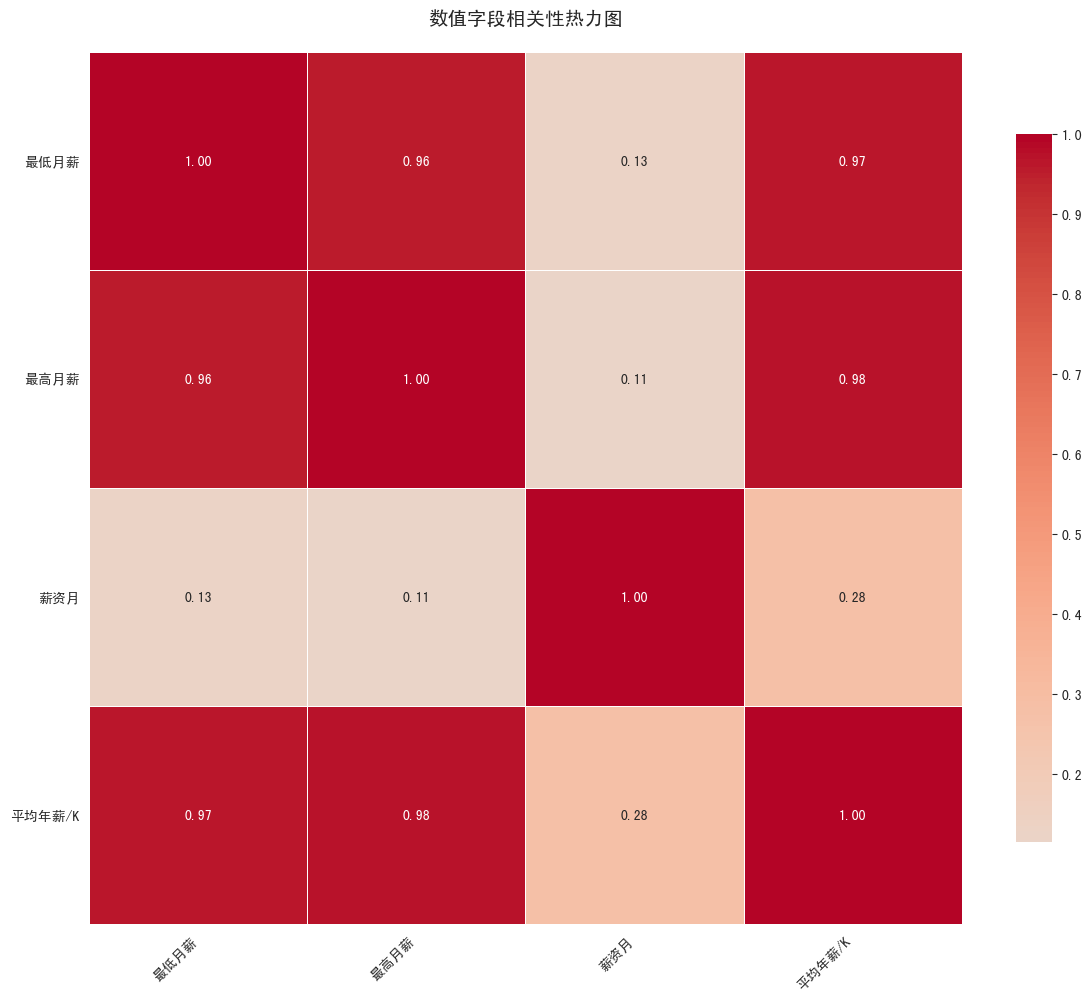


🔍 高相关性字段对（|相关系数| > 0.7）：
--------------------------------------------------------------------------------


,字段1,字段2,相关系数
0,最低月薪,最高月薪,0.957
1,最低月薪,平均年薪/K,0.966
2,最高月薪,平均年薪/K,0.976


In [20]:
# 计算数值字段的相关性矩阵
if len(numeric_cols) > 1:
    print("📊 数值字段相关性分析")
    print("=" * 80)
    
    # 计算相关性矩阵
    correlation_matrix = df[numeric_cols].corr()
    
    # 可视化相关性热力图
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, 
                annot=True,  # 显示相关系数
                fmt='.2f',   # 保留两位小数
                cmap='coolwarm',  # 颜色映射
                center=0,    # 以0为中心
                square=True, # 正方形格子
                linewidths=0.5,
                cbar_kws={"shrink": 0.8})
    plt.title('数值字段相关性热力图', fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # 找出高相关性的字段对（相关系数绝对值 > 0.7 且不是自身）
    print("\n🔍 高相关性字段对（|相关系数| > 0.7）：")
    print("-" * 80)
    high_corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.7:
                high_corr_pairs.append({
                    '字段1': correlation_matrix.columns[i],
                    '字段2': correlation_matrix.columns[j],
                    '相关系数': f"{correlation_matrix.iloc[i, j]:.3f}"
                })
    
    if high_corr_pairs:
        display(pd.DataFrame(high_corr_pairs))
    else:
        print("✅ 未发现高相关性的字段对")
else:
    print("⚠️  数值字段少于2个，无法进行相关性分析")


## 11. 数值字段异常值检测

**分析动机：** 异常值（离群点）可能表示：
1. 数据录入错误
2. 特殊情况或极端案例
3. 需要特别关注的数据点

通过箱线图（Box Plot）和统计方法检测异常值，可以：
- 评估数据质量
- 决定是否需要进行异常值处理
- 避免异常值对后续分析的影响

**检测方法：** 使用 IQR（四分位距）方法，超出 [Q1-1.5×IQR, Q3+1.5×IQR] 范围的值视为异常值。


📊 数值字段异常值检测


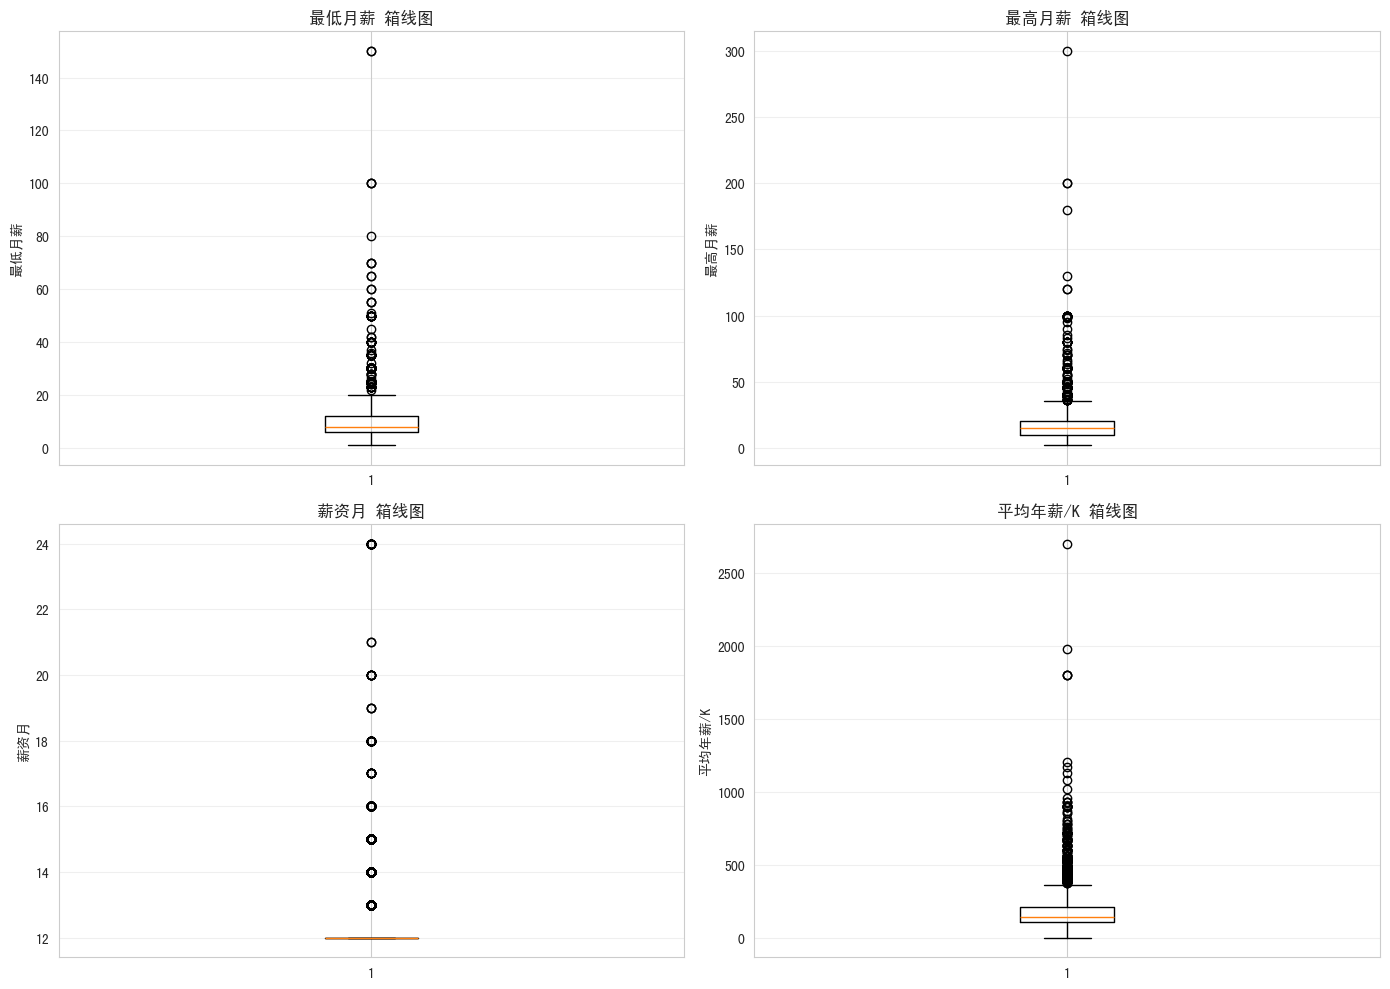


📋 异常值统计汇总：
--------------------------------------------------------------------------------


,字段名,异常值数量,异常值比例(%),下界,上界
0,最低月薪,330,3.79,-3.00,21.00
1,最高月薪,543,6.24,-5.00,35.00
2,薪资月,1362,15.65,12.00,12.00
3,平均年薪/K,402,4.62,-52.50,367.50


In [21]:
# 异常值检测和可视化
if len(numeric_cols) > 0:
    print("📊 数值字段异常值检测")
    print("=" * 80)
    
    # 选择前4个数值字段进行箱线图可视化
    cols_to_plot = numeric_cols[:4]
    
    if len(cols_to_plot) > 0:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        axes = axes.ravel()
        
        outlier_summary = []
        
        for idx, col in enumerate(cols_to_plot):
            if idx < len(axes):
                # 绘制箱线图
                axes[idx].boxplot(df[col].dropna(), vert=True)
                axes[idx].set_title(f'{col} 箱线图', fontsize=12, fontweight='bold')
                axes[idx].set_ylabel(col, fontsize=10)
                axes[idx].grid(axis='y', alpha=0.3)
                
                # 计算异常值
                Q1 = df[col].quantile(0.25)
                Q3 = df[col].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                
                outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
                outlier_summary.append({
                    '字段名': col,
                    '异常值数量': len(outliers),
                    '异常值比例(%)': f"{(len(outliers)/len(df)*100):.2f}",
                    '下界': f"{lower_bound:.2f}",
                    '上界': f"{upper_bound:.2f}"
                })
        
        # 隐藏多余的子图
        for idx in range(len(cols_to_plot), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # 显示异常值统计
        print("\n📋 异常值统计汇总：")
        print("-" * 80)
        display(pd.DataFrame(outlier_summary))
    
else:
    print("⚠️  没有数值型字段可以进行异常值检测")


## 12. 文本字段深入分析

**分析动机：** 对于招聘数据，文本字段往往包含重要的业务信息，如：
- 职位名称
- 公司名称  
- 工作地点
- 技能要求等

深入分析文本字段可以：
1. 了解数据的业务分布特征
2. 发现热门类别或趋势
3. 识别数据质量问题（如异常值、格式不一致）
4. 为后续的文本处理和分析提供依据


In [22]:
# 文本字段详细统计
if len(object_cols) > 0:
    print("📝 文本字段详细分析")
    print("=" * 80)
    
    text_field_stats = []
    
    for col in object_cols:
        # 统计信息
        total_count = len(df[col])
        null_count = df[col].isnull().sum()
        unique_count = df[col].nunique()
        
        # 计算数据丰富度（唯一值占比）
        richness = (unique_count / (total_count - null_count) * 100) if (total_count - null_count) > 0 else 0
        
        # 获取最常见的值
        if unique_count > 0:
            top_value = df[col].value_counts().head(1)
            top_val_name = top_value.index[0] if len(top_value) > 0 else 'N/A'
            top_val_count = top_value.values[0] if len(top_value) > 0 else 0
            top_val_ratio = (top_val_count / total_count * 100) if total_count > 0 else 0
        else:
            top_val_name = 'N/A'
            top_val_ratio = 0
        
        text_field_stats.append({
            '字段名': col,
            '总记录数': total_count,
            '缺失数': null_count,
            '唯一值数': unique_count,
            '数据丰富度(%)': f"{richness:.1f}",
            '最高频值': str(top_val_name)[:30],
            '最高频占比(%)': f"{top_val_ratio:.2f}"
        })
    
    stats_df = pd.DataFrame(text_field_stats)
    display(stats_df)
    
    print("\n💡 数据丰富度说明：")
    print("   • 接近100%：字段值高度分散，如ID、描述等")
    print("   • 接近0%：字段值高度集中，如类别、状态等")
    
else:
    print("⚠️  没有文本型字段可以分析")


📝 文本字段详细分析


,字段名,总记录数,缺失数,唯一值数,数据丰富度(%),最高频值,最高频占比(%)
0,岗位名称,8702,0,6586,75.7,房产经纪人,0.74
1,岗位薪资,8702,208,494,5.8,10k-20k,7.16
2,公司名称,8702,64,4136,47.9,北京麦田,6.87
3,公司部门,8702,401,4950,59.6,北京麦田,4.39
4,公司行业,8702,125,1000,11.7,居住服务,9.63
5,公司阶段,8702,424,71,0.9,不需要融资,30.92
6,公司规模,8702,1519,43,0.6,2000人以上,25.41
7,公司地址,8702,124,58,0.7,北京,28.68
8,经验要求,8702,63,7,0.1,在校应届,28.91
9,学历要求,8702,63,5,0.1,本科及以上,49.23



💡 数据丰富度说明：
   • 接近100%：字段值高度分散，如ID、描述等
   • 接近0%：字段值高度集中，如类别、状态等


---

**探索性分析完成！**

通过以上13个步骤的分析，我们已经完成了对招聘数据的全面探索。

下一步建议根据具体业务需求创建专项分析 Notebook。


In [23]:
# 生成探索性分析完整报告
print("=" * 100)
print(" " * 35 + "🎯 探索性分析完整报告")
print("=" * 100)

print(f"\n{'📊 数据概况':-^100}")
print(f"  ✓ 分析文件: {file_path}")
print(f"  ✓ 工作表数量: {len(sheet_names)}")
print(f"  ✓ 主分析对象: {main_sheet_name}")
print(f"  ✓ 数据规模: {df.shape[0]:,} 行 × {df.shape[1]} 列")
print(f"  ✓ 内存占用: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n{'📋 字段分析':-^100}")
print(f"  ✓ 数值型字段: {len(numeric_cols)} 个")
print(f"  ✓ 文本型字段: {len(object_cols)} 个")
print(f"  ✓ 其他字段: {len(df.columns) - len(numeric_cols) - len(object_cols)} 个")

print(f"\n{'🔍 数据质量':-^100}")
print(f"  ✓ 总缺失值: {missing_cells:,} 个 ({(missing_cells/total_cells*100):.2f}%)")
print(f"  ✓ 有缺失字段数: {len(missing_stats) if len(missing_stats) > 0 else 0} 个")
print(f"  ✓ 重复记录: {duplicates:,} 条 ({(duplicates/len(df)*100):.2f}%)")
print(f"  ✓ 数据质量评分: {total_score:.1f}/100.0 ({grade})")

print(f"\n{'💡 关键发现':-^100}")
print(f"  1. 数据集包含 {len(sheet_names)} 个工作表，主要分析 '{main_sheet_name}' ")
print(f"  2. 数据规模为 {df.shape[0]:,} 条记录，共 {df.shape[1]} 个字段")
print(f"  3. 整体数据质量评级为 '{grade}'")
if len(missing_stats) > 0:
    print(f"  4. 存在 {len(missing_stats)} 个字段有缺失值，需要关注")
else:
    print(f"  4. 数据完整性良好，无缺失值")
if duplicates > 0:
    print(f"  5. 发现 {duplicates:,} 条重复记录，建议后续处理")

print(f"\n{'🎯 后续分析建议':-^100}")
print(f"  📌 数据清洗：")
if len(missing_stats) > 0 or duplicates > 0:
    print(f"     • 处理缺失值（填充、删除或标记）")
    print(f"     • 处理重复记录")
else:
    print(f"     • 数据质量良好，可直接进行分析")
print(f"\n  📌 深入分析方向：")
print(f"     • 基于业务需求，选择关键字段进行专项分析")
print(f"     • 进行时间序列分析（如有时间字段）")
print(f"     • 探索分类字段之间的交叉分析")
print(f"     • 构建预测模型或推荐系统")
print(f"\n  📌 可视化建议：")
print(f"     • 创建交互式仪表板展示关键指标")
print(f"     • 绘制业务相关的专题图表")
print(f"     • 制作数据故事，向利益相关者展示洞察")

print(f"\n{'=' * 100}")
print(f"{' ' * 38}分析完成时间: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"{'=' * 100}\n")

print("✅ 探索性数据分析完成！接下来可以根据业务需求进行深入分析。")


                                   🎯 探索性分析完整报告

-----------------------------------------------📊 数据概况-----------------------------------------------
  ✓ 分析文件: datas/src/招聘数据总表_2510.xlsx
  ✓ 工作表数量: 8
  ✓ 主分析对象: 营销类
  ✓ 数据规模: 8,702 行 × 19 列
  ✓ 内存占用: 19.57 MB

-----------------------------------------------📋 字段分析-----------------------------------------------
  ✓ 数值型字段: 4 个
  ✓ 文本型字段: 15 个
  ✓ 其他字段: 0 个

-----------------------------------------------🔍 数据质量-----------------------------------------------


NameError: name 'missing_cells' is not defined

## 13. 数据完整性评分

**分析动机：** 为了全面评估数据质量，我们需要建立一个综合评分体系：

评分维度包括：
1. **完整性** - 无缺失值的字段比例
2. **唯一性** - 无重复记录
3. **一致性** - 数据格式统一，无明显异常

通过综合评分，可以：
- 快速判断数据是否可以直接用于分析
- 识别需要优先处理的数据质量问题
- 为数据清洗工作提供优先级指导


⭐ 数据质量综合评分

【评分详情】
  完整性评分: 39.0/40.0  (完整度: 97.5%)
  唯一性评分: 29.9/30.0  (无重复率: 99.8%)
  一致性评分: 6.3/30.0  (完整字段占比: 21.1%)

  总分: 75.3/100.0
  评级: 良好 ⭐⭐⭐⭐
  建议: 数据质量较好，建议进行简单清洗后使用


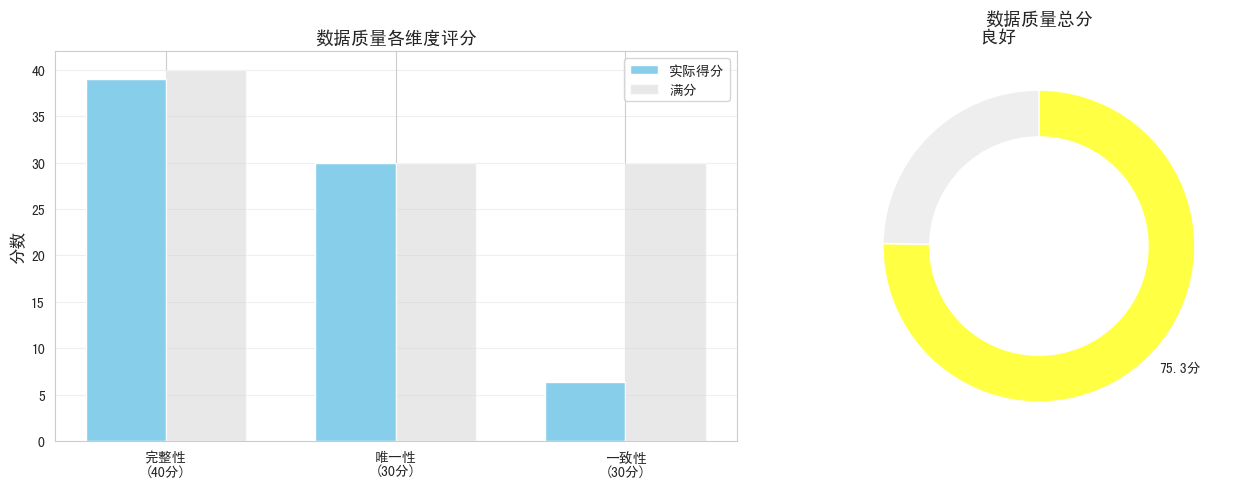

In [ ]:
# 数据质量综合评分
print("⭐ 数据质量综合评分")
print("=" * 80)

# 1. 完整性评分（0-40分）
total_cells = df.shape[0] * df.shape[1]
missing_cells = df.isnull().sum().sum()
completeness_ratio = (total_cells - missing_cells) / total_cells
completeness_score = completeness_ratio * 40

# 2. 唯一性评分（0-30分）
duplicate_ratio = duplicates / len(df) if len(df) > 0 else 0
uniqueness_score = (1 - duplicate_ratio) * 30

# 3. 一致性评分（0-30分）- 基于字段完整性
fields_without_missing = (df.isnull().sum() == 0).sum()
consistency_ratio = fields_without_missing / len(df.columns)
consistency_score = consistency_ratio * 30

# 总分
total_score = completeness_score + uniqueness_score + consistency_score

# 评级
if total_score >= 90:
    grade = "优秀 ⭐⭐⭐⭐⭐"
    comment = "数据质量很好，可以直接进行分析"
elif total_score >= 75:
    grade = "良好 ⭐⭐⭐⭐"
    comment = "数据质量较好，建议进行简单清洗后使用"
elif total_score >= 60:
    grade = "及格 ⭐⭐⭐"
    comment = "数据质量一般，需要进行清洗和处理"
else:
    grade = "待改进 ⭐⭐"
    comment = "数据质量较差，需要重点进行数据清洗"

# 显示评分结果
print(f"\n【评分详情】")
print(f"  完整性评分: {completeness_score:.1f}/40.0  (完整度: {completeness_ratio*100:.1f}%)")
print(f"  唯一性评分: {uniqueness_score:.1f}/30.0  (无重复率: {(1-duplicate_ratio)*100:.1f}%)")
print(f"  一致性评分: {consistency_score:.1f}/30.0  (完整字段占比: {consistency_ratio*100:.1f}%)")
print(f"\n{'='*80}")
print(f"  总分: {total_score:.1f}/100.0")
print(f"  评级: {grade}")
print(f"  建议: {comment}")
print(f"{'='*80}")

# 可视化评分
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：各维度评分
categories = ['完整性\n(40分)', '唯一性\n(30分)', '一致性\n(30分)']
scores = [completeness_score, uniqueness_score, consistency_score]
max_scores = [40, 30, 30]

x = np.arange(len(categories))
width = 0.35

ax1.bar(x - width/2, scores, width, label='实际得分', color='skyblue')
ax1.bar(x + width/2, max_scores, width, label='满分', color='lightgray', alpha=0.5)
ax1.set_ylabel('分数', fontsize=12)
ax1.set_title('数据质量各维度评分', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(categories)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 右图：总分仪表盘
colors = ['#ff4444', '#ffaa44', '#ffff44', '#44ff44']
if total_score < 60:
    color_idx = 0
elif total_score < 75:
    color_idx = 1
elif total_score < 90:
    color_idx = 2
else:
    color_idx = 3

ax2.pie([total_score, 100-total_score], 
        labels=[f'{total_score:.1f}分', ''],
        colors=[colors[color_idx], '#eeeeee'],
        startangle=90,
        counterclock=False,
        wedgeprops={'width': 0.3})
ax2.set_title(f'数据质量总分\n{grade}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
